# Einzelbaumerkennung und Vitalitäts-Screening

Dieses Notebook erkennt aus einem Kronenhöhenmodell die einzelnen Bäume einer
Waldfläche, grenzt ihre Kronen ab, misst pro Krone Höhe, Fläche und Farbe und
markiert Kronen, die deutlich weniger grün sind als der übrige Bestand.

**Datengrundlage:** Drohnenbefliegung Juli 2026 mit DJI Zenmuse L1 (LiDAR + RGB),
Waldfläche am ehemaligen Flughafen Tegel.

## Was vorher passiert sein muss

Das Notebook setzt vier Dateien voraus, die außerhalb entstehen (siehe die
separate Anleitung `Anleitung_Baumerkennung_LiDAR.md`):

| Datei | Entsteht durch |
|---|---|
| `dtm.tif` | PDAL-Pipeline `dtm.json` – Geländemodell aus den Bodenpunkten, 25 cm |
| `dsm.tif` | PDAL-Pipeline `dsm.json` – Oberflächenmodell aus allen Punkten, 25 cm |
| `geotiff/geotiff/dom_utm33.tif` | `gdalwarp` – Orthofoto nach EPSG:25833, 2 cm |
| `wald_polygon.gpkg` | in QGIS von Hand gezeichnete Abgrenzung der Waldfläche |

Alle Daten liegen in **EPSG:25833** (ETRS89 / UTM 33N), also in Metern. Das ist
wichtig, weil sämtliche Suchradien und Flächen in Metern gerechnet werden.

## Umgebung

```
python -m venv venv
venv\Scripts\activate
pip install rasterio scipy scikit-image geopandas matplotlib ipykernel
```

Nicht `pip install gdal` ausführen – das schlägt unter Windows fehl und wird
hier auch nicht gebraucht, weil `rasterio` GDAL bereits mitbringt.

## Zum Nachvollziehen

Nur **eine** Stelle muss angepasst werden: die Variable `base` in der zweiten
Codezelle. Danach die Zellen von oben nach unten ausführen. Laufzeit insgesamt
wenige Minuten, den größten Teil davon braucht die Farbauswertung.

**Ergebnisse dieses Durchlaufs** (Parameter `win = 7`):

| Kennzahl | Wert |
|---|---|
| gefundene Baumspitzen (gesamte Rasterfläche) | 3.851 |
| Bäume innerhalb des Waldpolygons | 1.812 |
| Baumdichte | 470 pro Hektar |
| als auffällig markierte Kronen | 26 |

## 1. Imports

- `rasterio` liest und schreibt georeferenzierte Rasterdaten (die .tif-Dateien).
- `geopandas` verwaltet die Kronenpolygone als Tabelle mit Geometriespalte.
- `scipy.ndimage` liefert die Bildoperationen (Glätten, lokale Maxima, Zusammenhangsanalyse).
- `skimage.segmentation.watershed` grenzt die Kronen voneinander ab.

Kein Paket für Punktwolken nötig: Die Punktwolke wurde bereits vorher mit PDAL
in die beiden Rasterdateien umgerechnet.

In [1]:
import numpy as np, rasterio, geopandas as gpd
from rasterio.mask import mask
from scipy import ndimage
from skimage.segmentation import watershed
from skimage.measure import regionprops

## 2. Kronenhöhenmodell berechnen und Baumspitzen finden

Hier passiert der Kern der Erkennung, in vier Gedankenschritten.

**Pfad anpassen.** `base` zeigt auf den Projektordner und ist die einzige Zeile,
die bei einem anderen Rechner geändert werden muss. Schrägstriche verwenden,
abschließenden Schrägstrich nicht vergessen.

**Kronenhöhenmodell (CHM).** Die Differenz aus Oberflächenmodell und
Geländemodell ergibt für jedes 25-cm-Pixel die Höhe der Vegetation *über dem
Boden*. Absolute Geländehöhen fallen dabei heraus, ein Baum auf einer Düne ist
damit genauso hoch wie derselbe Baum in einer Senke.

**Aufräumen.** Werte unter 2 m (Gras, Rollbahn, Unterwuchs) und über 45 m
(Messrauschen, Vögel, Fehlechos) werden auf 0 gesetzt, ebenso Pixel ohne Daten.
Der Medianfilter über 5 × 5 Pixel glättet die Krone: Ohne ihn würde jeder
einzelne Ast, der etwas höher steht, als eigener Baum erkannt.

**Baumspitzen.** Ein Pixel gilt als Baumspitze, wenn es im Fenster von
`win × win` Pixeln der höchste Punkt ist und über 5 m liegt (damit Büsche außen
vor bleiben). `ndimage.label` fasst benachbarte Spitzenpixel zu je einem Baum
zusammen und nummeriert sie durch.

**Kronen abgrenzen.** Das Watershed-Verfahren flutet das umgedrehte
Höhenmodell von jeder Baumspitze aus. Wo sich zwei „Wasser" treffen, verläuft
die Kronengrenze. Ergebnis ist das Array `crowns`, in dem jedes Pixel die Nummer
des Baums trägt, zu dem es gehört.

### Der Parameter `win` ist der zentrale Stellhebel

Er legt fest, wie weit zwei Spitzen mindestens auseinanderliegen müssen, um als
zwei Bäume zu gelten. Bei 25 cm Rasterweite entspricht `win = 7` rund 1,75 m.

- **zu klein** → eine große Krone zerfällt in mehrere „Bäume"
- **zu groß** → benachbarte Bäume verschmelzen zu einem

Für diesen Bestand hat `win = 7` am besten gepasst. Bei anderen Beständen
(schmalkronige Kiefern gegenüber ausladenden Buchen) kann ein anderer Wert
besser sein – dann `win` hier ändern und mit der nächsten Zelle prüfen.

**Ausgabe:** Anzahl der gefundenen Baumspitzen auf der gesamten Rasterfläche,
also inklusive Flugfeldrand. Die Zahl liegt daher über der späteren Baumzahl im
Wald.

In [2]:
base = "D:/Users/julius/projekte/SummerSchool/202606026_GB_Wald/"

with rasterio.open(base+"dsm.tif") as s, rasterio.open(base+"dtm.tif") as t:
    prof = s.profile
    chm = s.read(1).astype("float32") - t.read(1).astype("float32")

chm[~np.isfinite(chm)] = 0
chm[(chm < 2) | (chm > 45)] = 0          # Rollbahn, Gras, Ausreisser raus
chm = ndimage.median_filter(chm, size=5)  # glaetten, sonst zerfallen Kronen

win = 7  # Pixel; bei 25 cm Aufloesung entspricht das gut 1,75 m
mx = ndimage.maximum_filter(chm, size=win)
tops = (chm == mx) & (chm > 5)
labels, n = ndimage.label(tops)
print(f"{n} Baeume gefunden")

crowns = watershed(-chm, markers=labels, mask=chm > 2)

3851 Baeume gefunden


## 3. Sichtprüfung des Ergebnisses

Diese Zelle dient der Kalibrierung von `win` und ändert nichts an den Daten. Sie
zeigt einen 400 × 400 Pixel großen Ausschnitt (entspricht 100 × 100 m) des
Kronenhöhenmodells, eingefärbt nach Höhe, mit den erkannten Baumspitzen als rote
Punkte.

**So liest man das Bild:** Sitzt auf jeder erkennbaren Krone genau ein roter
Punkt, passt der Parameter. Mehrere Punkte auf einer Krone bedeuten, dass `win`
zu klein ist; Kronen ganz ohne Punkt bedeuten, dass `win` zu groß ist.

`r0, r1, c0, c1` verschieben den Ausschnitt. Es lohnt sich, mehrere Stellen
anzusehen – dichte und lockere Bereiche verhalten sich unterschiedlich. Liegt
der Ausschnitt über dem Flugfeld, ist das Bild einfarbig dunkel.

Nach jeder Änderung von `win` muss zuerst die vorige Zelle erneut laufen.

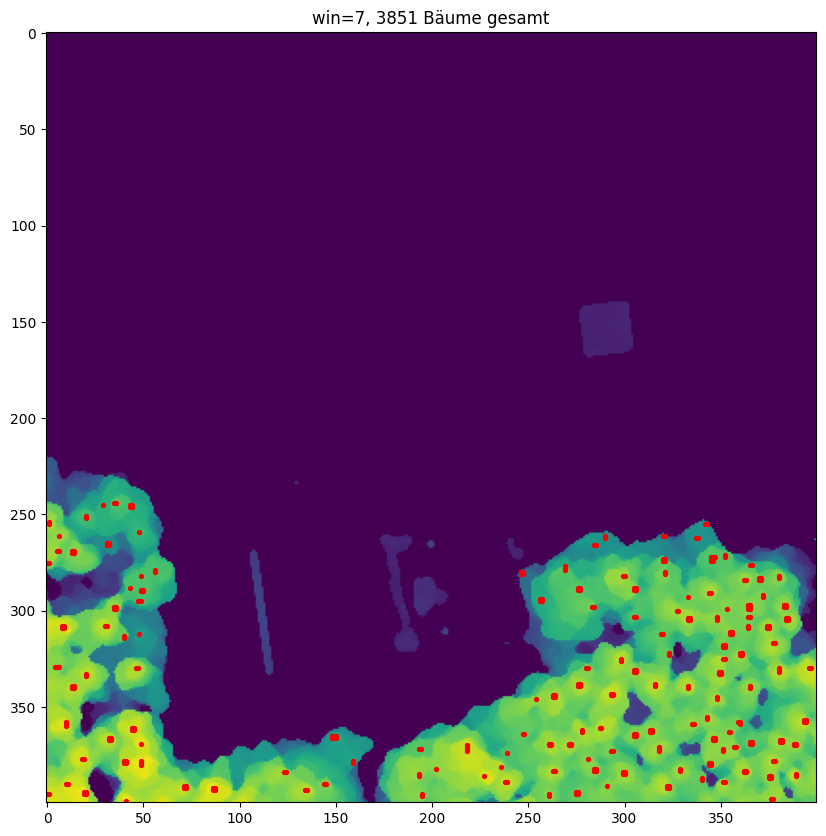

In [3]:
import matplotlib.pyplot as plt

r0, r1, c0, c1 = 400, 800, 400, 800   # Ausschnitt in Pixeln, 100 x 100 m
ys, xs = np.nonzero(tops[r0:r1, c0:c1])

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(chm[r0:r1, c0:c1], cmap="viridis")
ax.scatter(xs, ys, c="red", s=8)
ax.set_title(f"win={win}, {n} Bäume gesamt")
plt.show()

## 4. Kronen in Polygone umwandeln und vermessen

Bis hierher sind die Kronen nur ein Array aus Pixelnummern. Für Auswertung,
QGIS und Webkarte brauchen wir echte Geometrien.

`shapes()` wandelt zusammenhängende Pixel gleicher Nummer in Polygone um und
rechnet sie über `prof["transform"]` gleich in Meterkoordinaten um. Das
anschließende `dissolve` ist nötig, weil eine Krone gelegentlich in zwei
Teilflächen zerfällt, wenn sie nur über ein einzelnes Pixel zusammenhängt. 
Durch das `dissolve` erhalten wir wieder ein Polygon pro Baum.

Drei Attribute kommen dazu:

- **`hoehe_m`** – der höchste CHM-Wert innerhalb der Krone, also die Baumhöhe
  über Grund in Metern.
- **`flaeche_m2`** – die Kronengrundfläche in Quadratmetern.
- **`durchm_m`** – der Durchmesser eines flächengleichen Kreises. Eine Näherung,
  da echte Kronen nicht rund sind, aber für Vergleiche gut brauchbar.

**Ausgabe:** keine. Das Ergebnis steht in `gdf`; mit `gdf.head()` kann man
hineinschauen.

In [4]:
from rasterio.features import shapes
from shapely.geometry import shape

geoms, ids = [], []
for g, v in shapes(crowns.astype("int32"), mask=crowns > 0, transform=prof["transform"]):
    geoms.append(shape(g)); ids.append(int(v))

gdf = gpd.GeoDataFrame({"id": ids}, geometry=geoms, crs="EPSG:25833")
gdf = gdf.dissolve(by="id").reset_index()   # ein Polygon pro Baum

# Hoehe = hoechster CHM-Wert in der Krone
gdf["hoehe_m"] = ndimage.maximum(chm, labels=crowns, index=gdf["id"].values)
gdf["flaeche_m2"] = gdf.area
gdf["durchm_m"] = 2 * np.sqrt(gdf["flaeche_m2"] / np.pi)

gdf.head()

,id,geometry,hoehe_m,flaeche_m2,durchm_m
0,1,"POLYGON ((381818.41 5824205.36, 381818.41 5824...",6.000454,2.9375,1.933944
1,2,"POLYGON ((381817.66 5824200.61, 381817.66 5824...",5.116478,2.2500,1.692569
2,3,"POLYGON ((381804.16 5824197.61, 381804.16 5824...",7.700760,6.2500,2.820948
3,4,"POLYGON ((381806.66 5824198.86, 381806.66 5824...",8.501976,14.5000,4.296740
4,5,"POLYGON ((381810.91 5824199.86, 381810.91 5824...",8.354584,14.6250,4.315221


## 5. Auf die Waldfläche zuschneiden

Die Befliegung deckt auch Rollbahn, Taxiways und Straße ab. Das Waldpolygon aus
QGIS grenzt den auswertbaren Teil ab.

Gefiltert wird über den **Mittelpunkt** der Krone, nicht durch Verschneiden der
Polygone. Sonst entstünden am Waldrand halbe Kronen mit zu kleiner Fläche und
falschem Durchmesser. So bleibt jeder Baum entweder vollständig erhalten oder
fällt ganz heraus.

**Ausgabe:** Anzahl Bäume im Wald und die daraus berechnete Dichte pro Hektar.

> **Plausibilitätsprüfung:** 470 Bäume pro Hektar sind für einen Bestand mit
> älteren Bäumen viel; typisch sind je nach Alter und Art eher 200 bis 400. Das
> kann an einem jungen, dichten Bestand liegen, aber auch daran, dass große
> Kronen noch in mehrere Bäume zerlegt werden. 

In [5]:
wald = gpd.read_file(base + "wald_polygon.gpkg").to_crs(25833)
gdf = gdf[gdf.centroid.within(wald.union_all())].copy()
print(f"{len(gdf)} Bäume im Waldgebiet, {len(gdf) / (wald.area.sum() / 10000):.0f} pro ha")

1812 Bäume im Waldgebiet, 470 pro ha


## 6. Farbwerte pro Krone aus dem Orthofoto

Jetzt kommt die Bildinformation dazu. Das Orthofoto hat 2 cm Auflösung und liegt
damit auf einem viel feineren Raster als das CHM – deshalb wird es nicht als
Ganzes geladen, sondern für jede Krone einzeln ausschnittsweise gelesen. So
bleibt immer nur ein kleiner Teil der mehrere Gigabyte großen Datei im Speicher.

Drei Filter sorgen dafür, dass wirklich nur Kronenpixel gemessen werden:

- **`buffer(-0.3)`** – 30 cm vom Kronenrand werden weggeschnitten. Dort mischen
  sich sonst Nachbarkrone und Waldboden ins Bild.
- **gemeinsame Maske** über alle Kanäle – ein Pixel fliegt raus, sobald *ein*
  Kanal als NoData markiert ist. Ohne das hätten die Kanäle unterschiedlich
  viele Werte und die Rechnung bricht ab.
- **`a > 0` und Helligkeitssumme über 90** – blendet Pixel außerhalb des Bildes
  sowie tiefe Schatten aus. Schattenpixel würden gesunde Bäume dunkel und damit
  fälschlich „auffällig" erscheinen lassen.

Bleiben weniger als 50 brauchbare Pixel übrig, bekommt der Baum `NaN` statt
Messwerten und kann später nicht als auffällig gelten.

Vier neue Spalten entstehen: **`R`, `G`, `B`** als Mittelwerte der Kanäle und
**`gcc`** (Green Chromatic Coordinate) als Median von `G / (R + G + B)`, also dem
Grünanteil an der Gesamthelligkeit. Der GCC ist aussagekräftiger als die rohen
Farbwerte, weil Helligkeitsunterschiede durch Sonnenstand und Bewölkung
weitgehend herausfallen. Vitale Laubkronen liegen meist über etwa 0,38.

**Laufzeit:** je nach Anzahl Kronen und Festplatte ein bis fünf Minuten.
**Ausgabe:** keine.

In [6]:
from rasterio.mask import mask as rmask

rows = []
with rasterio.open(base + "geotiff/geotiff/dom_utm33.tif") as src:
    for geom in gdf.geometry:
        inner = geom.buffer(-0.3)
        if inner.is_empty:
            rows.append((np.nan,) * 4); continue
        arr, _ = rmask(src, [inner], crop=True, filled=False)
        m = np.ma.getmaskarray(arr).any(axis=0)          # gemeinsame Maske ueber alle Kanaele
        r, g, b, a = [band.data[~m].astype("float32") for band in arr]
        ok = (a > 0) & ((r + g + b) > 90)
        if ok.sum() < 50:
            rows.append((np.nan,) * 4); continue
        r, g, b = r[ok], g[ok], b[ok]
        s = r + g + b
        rows.append((r.mean(), g.mean(), b.mean(), np.median(g / s)))

gdf[["R", "G", "B", "gcc"]] = rows

## 7. Auffällige Kronen markieren und speichern

Die Bewertung erfolgt **relativ zum Bestand**, nicht gegen einen festen
Grenzwert. Das ist nötig, weil verschiedene Baumarten von Natur aus
unterschiedlich grün sind und wir die Arten nicht kennen.

Für jeden Baum wird berechnet, wie weit sein GCC vom Median aller Bäume entfernt
ist, gemessen in Standardabweichungen:

```
z = (gcc des Baums − Median aller gcc) / Standardabweichung aller gcc
```

`z = 0` heißt „genau typisch", `z = −1` heißt „eine Standardabweichung weniger
grün als üblich". **Als auffällig gilt ein Baum bei `z < −2`**, also wenn er
mehr als zwei Standardabweichungen unter dem typischen Wert liegt. Bei annähernd
normalverteilten Werten trifft das etwa 2 bis 3 % der Bäume.

> **Wichtig für die Interpretation:** Auffällig bedeutet „deutlich weniger grün
> als der übrige Bestand", nicht „krank". Auch in einem gesunden Wald gibt es
> immer einige Prozent Bäume unter dieser Schwelle; umgekehrt würde in einem
> großflächig geschädigten Bestand kaum ein Baum markiert, weil der Maßstab
> selbst gesunken ist. Typische Fehlalarme sind dunkle Nadelbäume, stark
> verschattete Kronen und Kronen mit viel sichtbarem Astwerk. Die Markierung ist
> ein Filter für die genauere Betrachtung, keine Diagnose.

**Ausgabe:** `baeume.gpkg` im Projektordner (für QGIS) sowie die Anzahl der
markierten Kronen in der Konsole.

In QGIS lässt sich die Datei über das Orthofoto legen und abgestuft nach `gcc`
einfärben; für die Durchsicht eignet sich eine regelbasierte Darstellung mit dem
Ausdruck `"auffaellig" = 1` und roter Umrandung ohne Füllung.

In [7]:
z = (gdf["gcc"] - gdf["gcc"].median()) / gdf["gcc"].std()
gdf["auffaellig"] = z < -2

gdf.to_file(base + "baeume.gpkg", driver="GPKG")
print(gdf["auffaellig"].sum(), "auffällige Kronen")

26 auffällige Kronen


## 8. Export als GeoJSON für die Webkarte

Für die MapLibre-Karte der Projektwebseite wird eine zweite, schlankere Fassung
geschrieben.

- **nur die benötigten Spalten**, damit die Datei klein bleibt.
- **`farbe`** – ein fertiger Hex-Farbwert pro Baum, damit die Webseite keine
  Farbskala nachbauen muss. Die Skala wird zwischen dem 2.- und 98.-Perzentil
  des GCC aufgespannt, damit einzelne Ausreißer sie nicht auseinanderziehen.
  Kronen ohne Messwert werden grau.
- **`z`** – der Z-Wert aus der vorigen Zelle. Damit kann die Webkarte die
  Einfärbung selbst steuern, ohne dass dieses Notebook erneut laufen muss.
- **`simplify(0.15)`** – glättet die Treppenkanten, die aus den 25-cm-Pixeln
  stammen, und verkleinert die Datei erheblich.
- **`to_crs(4326)`** – Webkarten erwarten Längen- und Breitengrad. Sieben
  Nachkommastellen entsprechen etwa einem Zentimeter, mehr braucht keine Karte.

**Ausgabe:** `baeume.geojson` im Projektordner. Für die Webseite gehört die
Datei nach `website/public/data/` und wird im Code als `/data/baeume.geojson`
eingebunden.

In [8]:
import matplotlib as mpl
import pandas as pd

web = gdf[["id", "hoehe_m", "durchm_m", "gcc", "auffaellig", "geometry"]].copy()

# Farbe schon hier berechnen, dann sieht es auf der Webseite aus wie in QGIS
lo, hi = web["gcc"].quantile([0.02, 0.98])
norm = mpl.colors.Normalize(lo, hi, clip=True)
cmap = mpl.colormaps["RdYlGn"]
web["farbe"] = [mpl.colors.to_hex(cmap(norm(v))) if pd.notna(v) else "#888888" for v in web["gcc"]]

# Treppenkanten der Pixel glätten, Werte runden
web["geometry"] = web.simplify(0.15)
web[["hoehe_m", "durchm_m"]] = web[["hoehe_m", "durchm_m"]].round(1)
web["gcc"] = web["gcc"].round(3)

web["z"] = z.round(2)
web.to_crs(4326).to_file(base + "baeume.geojson", driver="GeoJSON",
                          layer_options={"COORDINATE_PRECISION": 7})

## Grenzen der Auswertung

- **Nur die obere Kronenschicht.** Bäume unter dem Kronendach sind weder im Foto
  noch zuverlässig im Höhenmodell sichtbar.
- **Kein Nahinfrarot.** Der vierte Kanal des Orthofotos ist eine
  Transparenzmaske, kein NIR. Vegetationsindizes wie NDVI (Normalized Difference Vegetation Index) sind damit nicht
  möglich, die Beurteilung bleibt auf sichtbare (also eher fortgeschrittene)
  Veränderungen beschränkt.
- **Nur ein Aufnahmezeitpunkt.** Bäume lassen sich nur untereinander
  vergleichen, nicht mit ihrem eigenen früheren Zustand. Eine
  Wiederholungsbefliegung wäre der größte Gewinn an Aussagekraft.
- **Farbe ist unspezifisch.** Trockenheit, Schädlinge, Pilze und Wurzelschäden
  sehen aus der Luft ähnlich aus. Die Ursache klärt nur eine Kontrolle vor Ort.
- **Keine Artbestimmung.** Dafür bräuchte es zusätzliche Spektralkanäle und im
  Gelände bestimmte Referenzbäume als Trainingsdaten.